# Sentinel-3 OLCI L1 EFR → GeoZarr

This notebook demonstrates the Sentinel-3 OLCI exporter in `eopf-geozarr`:

1. **Open** an EOPF Zarr Sentinel-3 OLCI L1 EFR product.
2. **Detect** that it is an OLCI product.
3. **Convert** it to a GeoZarr-compliant, multiscale Zarr store.
4. **Visualize** the multiscale pyramid by rendering the same band from
   several overview levels, each on its **own native (decimated)
   latitude/longitude grid** — no resampling onto a shared grid.

OLCI is delivered as a **curvilinear swath** (per-pixel 2-D latitude/longitude,
no projected CRS). The exporter preserves that native geometry — it does not
reproject — and builds overviews by fill-aware 2×2 block averaging of the
radiance bands (coordinates are decimated to keep real measured positions).

> Requires the `notebooks` dependency group:
> `uv sync --group notebooks` (jupyter, matplotlib, nbformat).

In [1]:
import pathlib
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import zarr

from eopf_geozarr.s3_olci_optimization.olci_converter import (
    convert_olci_optimized,
    is_sentinel3_olci_dataset,
)
from eopf_geozarr.conversion.geozarr import get_zarr_group

## 1. Open an EOPF OLCI product

We open a real Sentinel-3 OLCI L1 EFR product from the EOPF sample store on
EODC. If the store is unreachable (offline / CI), we fall back to the small
structure-only test fixture shipped with the repository so the notebook still
runs end to end.

EOPF radiance is stored as scaled `uint16`; we open with `mask_and_scale=False`
so the raw integers and their `scale_factor` / `_FillValue` are preserved for a
faithful conversion (the converter expects un-decoded input).

In [2]:
# A real OLCI L1 EFR product on the EODC EOPF sample store (use an _NT_,
# fully-consolidated product — _NR_ near-real-time copies may lack metadata).
EODC_OLCI_URL = (
    "https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:202511-s03olcefr-eu/"
    "01/products/cpm_v262/"
    "S3A_OL_1_EFR____20251101T073957_20251101T074257_20251102T084255_"
    "0179_132_149_2160_PS1_O_NT_004.zarr"
)


def open_olci_input() -> xr.DataTree:
    """Open the remote OLCI product; fall back to the repo test fixture offline."""
    try:
        dt = xr.open_datatree(
            EODC_OLCI_URL, engine="zarr", chunks={}, mask_and_scale=False
        )
        print("Opened remote EODC OLCI product.")
        return dt
    except Exception as exc:  # noqa: BLE001 - notebook offline fallback
        print(f"Remote open failed ({type(exc).__name__}); using bundled fixture.")
        import sys

        # Resolve the repo root regardless of the kernel's working directory
        # (interactive runs start in docs/notebooks/, CI may start at the root).
        repo_root = next(
            p
            for p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents)
            if (p / "tests" / "_test_data").exists()
        )
        if str(repo_root) not in sys.path:
            sys.path.insert(0, str(repo_root))
        from tests.conftest import create_group_from_json

        fixture = repo_root / (
            "tests/_test_data/s3_examples/"
            "S3A_OL_1_EFR____20251101T073957_20251101T074257_20251102T084255_"
            "0179_132_149_2160_PS1_O_NT_004.json"
        )
        store = create_group_from_json(fixture, pathlib.Path(tempfile.mkdtemp()))
        return xr.open_datatree(store, engine="zarr", mask_and_scale=False)


dt_input = open_olci_input()
print("Top-level groups:", sorted(dt_input.groups))

Opened remote EODC OLCI product.
Top-level groups: ['/', '/conditions', '/conditions/geometry', '/conditions/image', '/conditions/instrument', '/conditions/meteorology', '/conditions/orphans', '/measurements', '/measurements/orphans', '/quality', '/quality/orphans']


### Inspect the measurements group

OLCI L1 EFR carries 21 radiance bands (`oa01_radiance` … `oa21_radiance`) on a
single full-resolution grid, geolocated by per-pixel 2-D `latitude` /
`longitude` coordinate arrays.

In [3]:
meas = dt_input["/measurements"].to_dataset()
bands = [v for v in meas.data_vars if str(v).endswith("_radiance")]
print(f"{len(bands)} radiance bands; e.g. {bands[:3]} … {bands[-1]}")
oa = meas["oa01_radiance"]
print("oa01_radiance:", oa.shape, oa.dtype, "| dims", oa.dims)
print("scale_factor:", oa.attrs.get("scale_factor"), "| _FillValue:", oa.attrs.get("_FillValue"))
print("geolocation coords:", [c for c in ("latitude", "longitude", "altitude") if c in meas])

21 radiance bands; e.g. ['oa01_radiance', 'oa02_radiance', 'oa03_radiance'] … oa21_radiance
oa01_radiance: (4090, 4865) uint16 | dims ('rows', 'columns')
scale_factor: 0.013946459628641605 | _FillValue: 65535
geolocation coords: ['latitude', 'longitude', 'altitude']


## 2. Detect the product type

Detection is structural: a product is OLCI iff it validates against the OLCI
data model and its measurements group contains the radiance bands.

In [4]:
group = get_zarr_group(dt_input)
print("is_sentinel3_olci_dataset:", is_sentinel3_olci_dataset(group))

is_sentinel3_olci_dataset: True


## 3. Convert to GeoZarr

`convert_olci_optimized` writes the native measurements group plus `/2`
block-averaged overview subgroups (`r2`, `r4`, …) down to `min_dimension`, and
declares them with the GeoZarr `multiscales` convention. `conditions` and
`quality` are copied through unchanged.

We use a small `min_dimension` here so even the small sample yields several
overview levels to visualize.

In [5]:
output_path = str(pathlib.Path(tempfile.mkdtemp()) / "olci_geozarr.zarr")
convert_olci_optimized(dt_input, output_path=output_path, min_dimension=4)

store = zarr.open_group(output_path, mode="r")
# Overview levels are the rN subgroups under measurements (exclude e.g. orphans).
levels = ["."] + sorted(
    (k for k in store["measurements"].group_keys() if k.startswith("r")),
    key=lambda k: int(k[1:]),
)
print("Pyramid levels (native + overviews):", levels)

2026-07-07 13:01:37 [info     ] Writing native-resolution measurements shape={'rows': 4090, 'columns': 4865}


2026-07-07 13:02:00 [info     ] Generating overview levels     n_levels=9


2026-07-07 13:03:03 [info     ] Writing overview               group=measurements/r2 shape={'rows': 2045, 'columns': 2432}


2026-07-07 13:03:52 [info     ] Writing overview               group=measurements/r4 shape={'rows': 1022, 'columns': 1216}


2026-07-07 13:04:41 [info     ] Writing overview               group=measurements/r8 shape={'rows': 511, 'columns': 608}


...

2026-07-07 13:09:46 [info     ] Copying ancillary subgroup     group=quality


2026-07-07 13:09:55 [info     ] Copying ancillary subgroup     group=quality/orphans


2026-07-07 13:09:56 [info     ] Copying measurements subgroup  group=measurements/orphans


2026-07-07 13:09:56 [info     ] Copying ancillary subgroup     group=measurements/orphans


Pyramid levels (native + overviews): ['.', 'r2', 'r4', 'r8', 'r16', 'r32', 'r64', 'r128', 'r256', 'r512']


### Load every pyramid level

Level `.` is the native resolution written at the measurements group root;
`r2`, `r4`, … are successively coarser block-averaged overviews. Each level is
opened as a Dataset so we get the radiance band **together with that level's
own decimated `latitude`/`longitude` coordinates**. We read with default
decoding so the stored `uint16` radiance is scaled to physical units (and fill
pixels become NaN) for display.

In [6]:
BAND = "oa08_radiance"  # ~665 nm (red); good visual contrast


def read_level(level: str) -> xr.Dataset:
    """Open one pyramid level as a Dataset (band + its decimated lat/lon)."""
    group = "measurements" if level == "." else f"measurements/{level}"
    return xr.open_dataset(output_path, engine="zarr", group=group, consolidated=False)


level_datasets = {lvl: read_level(lvl) for lvl in levels}
for lvl, ds in level_datasets.items():
    print(f"{lvl:>4}: shape {tuple(ds[BAND].shape)}")

   .: shape (4090, 4865)
  r2: shape (2045, 2432)
  r4: shape (1022, 1216)
  r8: shape (511, 608)
 r16: shape (255, 304)
 r32: shape (127, 152)
 r64: shape (63, 76)
r128: shape (31, 38)
r256: shape (15, 19)
r512: shape (7, 9)


## 4. Each pyramid level on its own native grid

Each panel below draws one level **exactly as stored**: that level's radiance
array plotted against its own decimated 2-D latitude/longitude coordinates
with `pcolormesh`. Nothing is resampled onto a shared grid — every panel
covers the same swath in geographic coordinates, while the native cells get
4× larger (2× per axis) with each level shown.

The finest levels (native, `r2`, `r4`) are stored identically but skipped
here only because `pcolormesh` with millions of quads is slow to render; we
pick four levels spanning the affordable range down to the coarsest.

Levels shown: ['r8', 'r32', 'r128', 'r512']


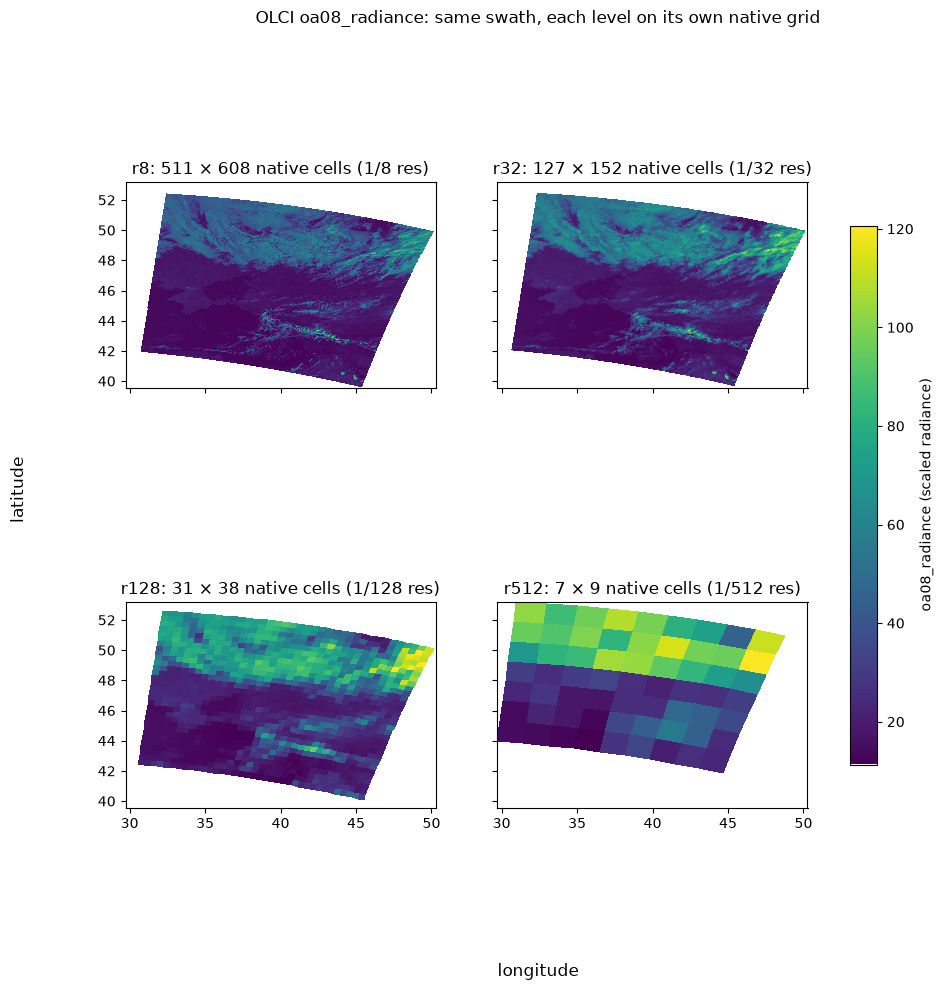

In [7]:
# Pick four levels: the finest that is still cheap to draw as quads, through
# the coarsest available (deduplicated for small fixture inputs).
MAX_CELLS = 600_000
candidates = [lvl for lvl in levels if level_datasets[lvl][BAND].size <= MAX_CELLS]
pick = sorted(set(np.linspace(0, len(candidates) - 1, 4).round().astype(int)))
show_levels = [candidates[i] for i in pick]
print("Levels shown:", show_levels)

fig, axes = plt.subplots(2, 2, figsize=(11, 10), sharex=True, sharey=True)
for ax in axes.flat[len(show_levels) :]:
    ax.set_visible(False)
for ax, lvl in zip(axes.flat, show_levels):
    ds = level_datasets[lvl]
    band = ds[BAND]
    # This level's own decimated coordinates: the native grid of the level.
    mesh = ax.pcolormesh(
        ds["longitude"],
        ds["latitude"],
        band,
        cmap="viridis",
        shading="nearest",
        rasterized=True,
    )
    res = 1 if lvl == "." else int(lvl[1:])
    name = "native" if lvl == "." else lvl
    ax.set_title(f"{name}: {band.shape[0]} × {band.shape[1]} native cells (1/{res} res)")
    ax.set_aspect("equal")
fig.supxlabel("longitude")
fig.supylabel("latitude")
fig.colorbar(mesh, ax=axes, shrink=0.7, label=f"{BAND} (scaled radiance)")
fig.suptitle(f"OLCI {BAND}: same swath, each level on its own native grid")
plt.show()

All panels cover the same geographic swath, but each is drawn from that
level's own stored arrays — radiance plus its decimated latitude/longitude —
so the visible cell size is the level's true native resolution. The
coarsening from panel to panel is the multiscale pyramid itself, produced by
the single conversion above.